# EDA: Imitation Learning — v21 Hybrid vs v22 Pure

This notebook audits **how** the two imitation-learning agents decide, then measures
whether those architectural differences show up in the 10k-game round-robin.

Both agents clone expert *macro* behaviour (move vs switch) from the same 1,150-feature
XGBoost model trained on human gen9randombattle turns. They **diverge after that prediction**:

| | **v21 (`HeuristicV21XGBoost`)** | **v22 (`HeuristicV22PureIL`)** |
|---|---|---|
| Inheritance | Full `HeuristicV14` (damage math, roles, Tera, Yomi) | `BaseHeuristic1v1` only — **no v14** |
| Macro policy | Same XGBoost (`xgboost_advanced_model.json`) | Same XGBoost |
| Switch threshold | `xgboost_advanced_threshold.json` (recommended **0.5525**) | Same file |
| Before XGBoost | Guaranteed KO → endgame minimax (≤2 mons) → setup reaction → status absorb | Nothing — XGBoost is first |
| If XGB says *switch* | Pivot move (U-turn / Volt Switch) **or** v14 `_get_best_switch` | **Counterfactual**: score every bench mon as if it were active, pick lowest $p(\text{switch})$ |
| If XGB says *move* | v14 `_score_move` (type, STAB, KO, speed) | Second model `xgboost_move_evaluator.json` |
| Overrides | Weak-move tactical switch-back to v14 | Loop guard only |
| Telemetry unique to hybrid | `ko_guards_us`, `endgame_solves_us`, v14 search counters | Should stay ~0 |

```
Turn (v21)          Turn (v22)
─────────────       ──────────────────────────
forced faint? ──┐   forced faint? ── counterfactual switch
guaranteed KO ──┤
endgame minimax─┤
setup / absorb ─┤
XGBoost p_switch┤   XGBoost p_switch
  ≥ τ → switch  │     ≥ τ → counterfactual switch
  < τ → v14 move┘     < τ → move-evaluator XGB
```

Benchmark: `data/benchmarks/all_10k/gen9randombattle` — each agent as **us** vs all 28 opponents
(10k games, or 1k vs v18/v19/v20).


In [1]:
# Setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data/benchmarks/all_10k/gen9randombattle").exists():
    ROOT = ROOT.parent
BENCHMARK_DIR = ROOT / "data/benchmarks/all_10k/gen9randombattle"
OUTPUT_DIR = ROOT / "src/p00_core/reporting/agents/il_v21_v22"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AGENTS = ["v21", "v22"]
AGENT_LABEL = {
    "v21": "v21 Hybrid (XGB + v14)",
    "v22": "v22 Pure IL (two XGBs)",
}
AGENT_COLOR = {"v21": "#6B4C9A", "v22": "#1A7A6D"}

PARADIGM_MAP = {
    "random": "Baseline",
    "max_power": "Baseline",
    "abyssal": "Baseline",
    "one_step": "Baseline",
    "safe_one_step": "Baseline",
    "simple_heuristic": "Baseline",
    **{f"v{i}": "Heuristic" for i in range(1, 15)},
    "v15": "Minimax",
    "v16": "Minimax",
    "v17": "Minimax",
    "v18": "MCTS",
    "v19": "MCTS",
    "v20": "MCTS",
    "v21": "IL Hybrid",
    "v22": "IL Pure",
}
PARADIGM_ORDER = ["Baseline", "Heuristic", "Minimax", "MCTS", "IL Hybrid", "IL Pure"]
REDUCED = {"v18", "v19", "v20"}

IL_COLS = [
    "ko_guards_us", "loop_guards_us", "xgb_switches_us", "xgb_stays_us",
    "xgb_prob_sum_us", "endgame_solves_us", "search_switches_us", "search_moves_us",
    "total_turns_us",
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (11, 5.5), "font.size": 11, "savefig.dpi": 160})


def wilson_ci(wins: float, n: float, z: float = 1.96) -> float:
    """Half-width of a 95% Wilson interval, in percentage points."""
    if n <= 0:
        return 0.0
    p = wins / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return float(margin * 100)


print(f"Root        : {ROOT}")
print(f"Benchmark   : {BENCHMARK_DIR}")
print(f"Export      : {OUTPUT_DIR}")
print(f"Agents      : {AGENTS}")

th_path = ROOT / "src/p02_imitation_learning/s03_training/models/gen9randombattle/xgboost_advanced_threshold.json"
if th_path.exists():
    import json as _json
    th = _json.loads(th_path.read_text())
    print("\nShared macro-policy threshold (both agents):")
    for k, v in th.items():
        print(f"  {k}: {v}")
    print("  → both agents switch iff p(switch) ≥ recommended_threshold")
else:
    print(f"\nThreshold file missing at {th_path}")


Root        : /home/sirp/Documents/MUDS/TFM_Pokemon
Benchmark   : /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Export      : /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/il_v21_v22
Agents      : ['v21', 'v22']

Shared macro-policy threshold (both agents):
  f1_optimal_threshold: 0.48
  f1_score: 0.5063
  frequency_matched_threshold: 0.625
  true_switch_rate: 0.2585
  recommended_threshold: 0.5525
  → both agents switch iff p(switch) ≥ recommended_threshold


## 1 · Load both agents as *us*

Each row is one finished battle. `agent` is who sat in the recording seat (`heuristic` column).
Matchups vs v18/v19/v20 have 1,000 games; all others 10,000.


In [2]:
# Load v21_* and v22_* as player
INT_FILL = [
    "won", "turns", "decisions_us", "fallback_moves_us", "error_moves_us",
    "fainted_us", "remaining_pokemon_us", "fainted_opp", "remaining_pokemon_opp",
    "voluntary_switches_us", "forced_switches_us", "voluntary_switches_opp",
    "forced_switches_opp", "supereffective_us", "supereffective_opp",
    "hazard_sets_us", "setup_uses_us", "ko_checks_us", "matchup_switches_us",
    "terastallized_us", *IL_COLS,
]


def load_agent(agent: str) -> pd.DataFrame:
    files = sorted(BENCHMARK_DIR.glob(f"{agent}_vs_*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs for {agent} in {BENCHMARK_DIR}")
    parts = []
    for path in files:
        df = pd.read_csv(path)
        df["agent"] = agent
        df["matchup_opponent"] = df["opponent"]
        parts.append(df)
    out = pd.concat(parts, ignore_index=True)
    for col in INT_FILL:
        if col not in out.columns:
            out[col] = 0
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0)
    out["won_bool"] = out["won"].astype(int)
    out["opponent_paradigm"] = out["matchup_opponent"].map(lambda x: PARADIGM_MAP.get(x, "Other"))
    out["xgb_decisions"] = out["xgb_switches_us"] + out["xgb_stays_us"]
    turns = out["total_turns_us"].replace(0, np.nan)
    out["p_switch_mean"] = out["xgb_prob_sum_us"] / turns
    out["xgb_switch_share"] = out["xgb_switches_us"] / out["xgb_decisions"].replace(0, np.nan)
    out["xgb_fire_rate"] = out["xgb_decisions"] / turns
    out["endgame_rate"] = out["endgame_solves_us"] / turns
    out["ko_guard_rate"] = out["ko_guards_us"] / turns
    out["loop_guard_rate"] = out["loop_guards_us"] / turns
    return out


frames = {ag: load_agent(ag) for ag in AGENTS}
df = pd.concat(frames.values(), ignore_index=True)

print("Games loaded")
for ag, g in frames.items():
    n_files = g.groupby("matchup_opponent").ngroups
    print(f"  {ag}: {len(g):>8,} games  |  {n_files} opponents  |  WR {g['won_bool'].mean()*100:.2f}%")
print(f"  total: {len(df):,} rows  |  columns {df.shape[1]}")


Games loaded
  v21:  253,000 games  |  28 opponents  |  WR 58.71%
  v22:  253,000 games  |  28 opponents  |  WR 33.49%
  total: 506,000 rows  |  columns 81


## 2 · Headline: same gauntlet, two policies

If v21 and v22 were “the same IL agent with a different label”, overall win rate, XGB fire
rate, and hybrid-only counters would line up. They should not.


In [3]:
# Headline table
rows = []
for ag, g in frames.items():
    n = len(g)
    wins = int(g["won_bool"].sum())
    turns = g["total_turns_us"].replace(0, np.nan)
    rows.append({
        "agent": AGENT_LABEL[ag],
        "games": n,
        "win_rate_%": 100 * wins / n,
        "ci95_pp": wilson_ci(wins, n),
        "avg_turns": g["turns"].mean(),
        "avg_hp_us": g["remaining_pokemon_us"].mean(),
        "vol_switches": g["voluntary_switches_us"].mean(),
        "xgb_fire_%_turns": 100 * g["xgb_fire_rate"].mean(),
        "xgb_switch_share_%": 100 * g["xgb_switch_share"].mean(),
        "mean_p_switch": g["p_switch_mean"].mean(),
        "ko_guards / game": g["ko_guards_us"].mean(),
        "endgame / game": g["endgame_solves_us"].mean(),
        "loop_guards / game": g["loop_guards_us"].mean(),
        "fallback / game": g["fallback_moves_us"].mean(),
        "error / game": g["error_moves_us"].mean(),
    })

headline = pd.DataFrame(rows).set_index("agent")
headline.to_csv(OUTPUT_DIR / "il_headline_comparison.csv")
headline.T


## 3 · Architectural fingerprint — proof they are not the same stack

v21 injects **search and v14 tactics before** the imitation policy. Those events are
counted in `ko_guards_us` and `endgame_solves_us`. v22 never calls those functions, so
the same columns must be ~0. `xgb_fire_rate` (share of turns that reached the XGBoost
macro head) should therefore be **lower for v21**.


Mean counts per game (and rates)
agent                v21    v22
ko_guards_us      13.847  0.000
endgame_solves_us  0.032  0.000
ko_checks_us       0.631  0.000
search_moves_us    0.000  0.000
xgb_stays_us       2.668 17.191
xgb_switches_us    0.969  2.875
loop_guards_us     0.382  1.920
fallback_moves_us  0.000  0.011
xgb_fire_rate      0.152  0.799
p_switch_mean      0.080  0.351

--- v22 purity checks (hybrid / v14 machinery should be ~0) ---
  ko_guards_us            mean=0.0000  max=0  nonzero=0.000% of games
  endgame_solves_us       mean=0.0000  max=0  nonzero=0.000% of games
  ko_checks_us            mean=0.0000  max=0  nonzero=0.000% of games
  search_moves_us         mean=0.0000  max=0  nonzero=0.000% of games
  search_switches_us      mean=0.0000  max=0  nonzero=0.000% of games


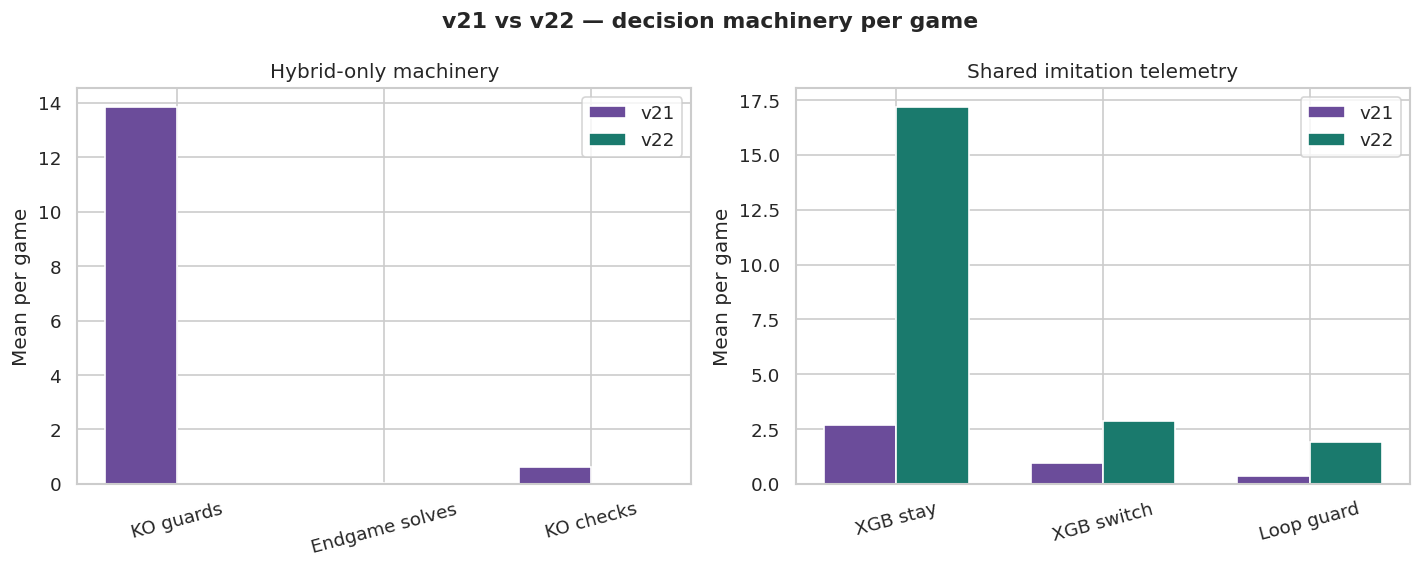

In [4]:
# Fingerprint: hybrid-only vs shared IL telemetry
fp_cols = {
    "ko_guards_us": "KO guards (v14 guaranteed KO)",
    "endgame_solves_us": "Endgame minimax solves",
    "ko_checks_us": "KO-check flags (v14 scorer)",
    "search_moves_us": "Search move picks (MCTS leftover)",
    "xgb_stays_us": "XGB predicted MOVE (stay)",
    "xgb_switches_us": "XGB predicted SWITCH",
    "loop_guards_us": "Anti-oscillation loop guard",
    "fallback_moves_us": "Engine fallbacks",
}

fp = []
for ag, g in frames.items():
    rec = {"agent": ag}
    for col, _ in fp_cols.items():
        rec[col] = g[col].mean()
    rec["xgb_fire_rate"] = g["xgb_fire_rate"].mean()
    rec["p_switch_mean"] = g["p_switch_mean"].mean()
    fp.append(rec)
fp_df = pd.DataFrame(fp).set_index("agent")

print("Mean counts per game (and rates)")
display_cols = list(fp_cols) + ["xgb_fire_rate", "p_switch_mean"]
print(fp_df[display_cols].T.to_string())

# v22 must not be using the hybrid stack
v22 = frames["v22"]
print("\n--- v22 purity checks (hybrid / v14 machinery should be ~0) ---")
for col in ["ko_guards_us", "endgame_solves_us", "ko_checks_us", "search_moves_us", "search_switches_us"]:
    s = v22[col]
    print(f"  {col:22s}  mean={s.mean():.4f}  max={s.max():.0f}  nonzero={(s > 0).mean()*100:.3f}% of games")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

hybrid = ["ko_guards_us", "endgame_solves_us", "ko_checks_us"]
x = np.arange(len(hybrid))
w = 0.35
axes[0].bar(x - w / 2, fp_df.loc["v21", hybrid], w, color=AGENT_COLOR["v21"], label="v21")
axes[0].bar(x + w / 2, fp_df.loc["v22", hybrid], w, color=AGENT_COLOR["v22"], label="v22")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["KO guards", "Endgame solves", "KO checks"], rotation=15)
axes[0].set_ylabel("Mean per game")
axes[0].set_title("Hybrid-only machinery")
axes[0].legend()

shared = ["xgb_stays_us", "xgb_switches_us", "loop_guards_us"]
axes[1].bar(x - w / 2, fp_df.loc["v21", shared], w, color=AGENT_COLOR["v21"], label="v21")
axes[1].bar(x + w / 2, fp_df.loc["v22", shared], w, color=AGENT_COLOR["v22"], label="v22")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["XGB stay", "XGB switch", "Loop guard"], rotation=15)
axes[1].set_ylabel("Mean per game")
axes[1].set_title("Shared imitation telemetry")
axes[1].legend()

fig.suptitle("v21 vs v22 — decision machinery per game", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_fingerprint_bars.png")
plt.show()


## 4 · How the imitation policy actually fires

`xgb_prob_sum_us / total_turns_us` is the mean predicted $p(\text{switch})$ that the macro
model emitted (including turns that later got overridden). Density of that mean, plus the
stay/switch mix, shows whether v22 is a “switchier” clone of the expert or whether v21’s
pre-filters change the distribution the model sees.


XGB fire rate (fraction of turns that reached the macro head)
  v21: 15.2% of turns
  v22: 79.9% of turns

Among XGB decisions, share predicted SWITCH
  v21: 35.5%
  v22: 15.2%


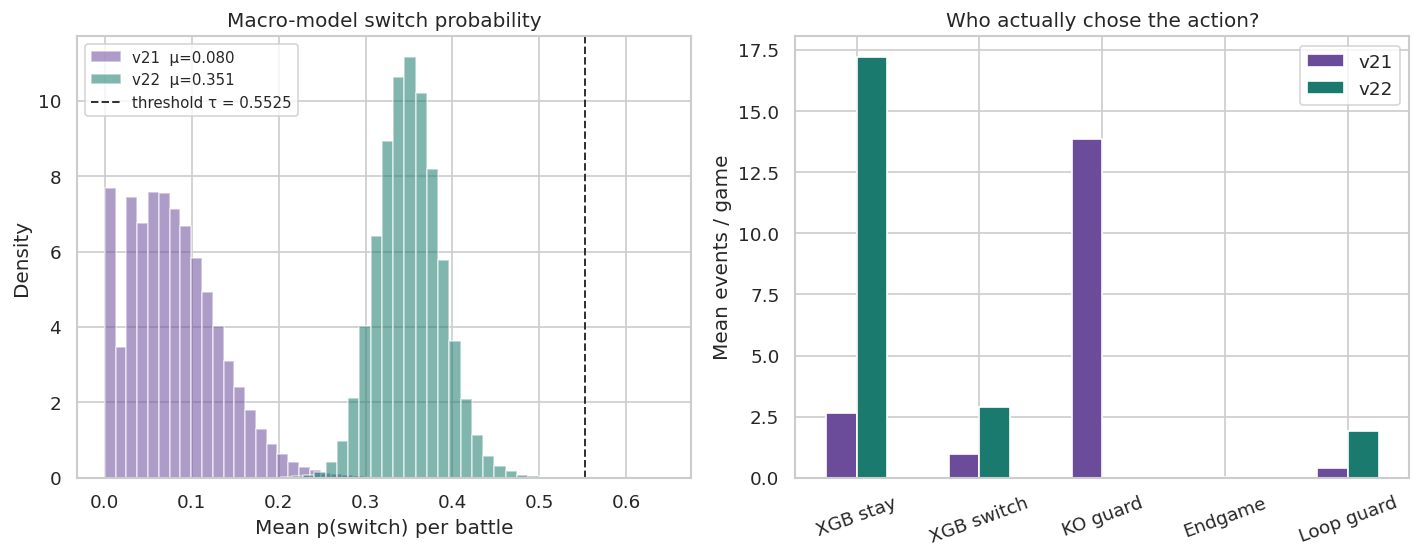

In [5]:
# Policy firing: p(switch) and stay/switch mix
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ag, g in frames.items():
    vals = g["p_switch_mean"].dropna()
    axes[0].hist(vals, bins=40, density=True, alpha=0.55, color=AGENT_COLOR[ag],
                 label=f"{ag}  μ={vals.mean():.3f}")
axes[0].axvline(0.5525, color="#333", ls="--", lw=1.2, label="threshold τ = 0.5525")
axes[0].set_xlabel("Mean p(switch) per battle")
axes[0].set_ylabel("Density")
axes[0].set_title("Macro-model switch probability")
axes[0].legend(fontsize=9)

mix = pd.DataFrame({
    ag: [
        g["xgb_stays_us"].mean(),
        g["xgb_switches_us"].mean(),
        g["ko_guards_us"].mean(),
        g["endgame_solves_us"].mean(),
        g["loop_guards_us"].mean(),
    ]
    for ag, g in frames.items()
}, index=["XGB stay", "XGB switch", "KO guard", "Endgame", "Loop guard"])
mix.plot(kind="bar", ax=axes[1], color=[AGENT_COLOR["v21"], AGENT_COLOR["v22"]], rot=20)
axes[1].set_ylabel("Mean events / game")
axes[1].set_title("Who actually chose the action?")
axes[1].legend(title="")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_policy_firing.png")
plt.show()

print("XGB fire rate (fraction of turns that reached the macro head)")
for ag, g in frames.items():
    print(f"  {ag}: {100*g['xgb_fire_rate'].mean():.1f}% of turns")
print("\nAmong XGB decisions, share predicted SWITCH")
for ag, g in frames.items():
    print(f"  {ag}: {100*g['xgb_switch_share'].mean():.1f}%")


## 5 · Win rate across the same opponents

Grouped bars: v21 and v22 against every opponent. MCTS cells (v18–v20) are 1k games;
error bars are 95% Wilson intervals.


v21 beats v22 in 28 / 28 matchups
Mean delta (v21 − v22): +25.24 pp

Largest gaps (v21 − v22):
matchup_opponent
safe_one_step   32.640
v3              31.030
one_step        30.510
v5              30.240
v1              30.220
v6              30.180

Smallest gaps (v21 − v22); v21 is ahead in every matchup if all values are positive:
matchup_opponent
random    1.940
v13      16.360
v14      19.620
v21      20.850
v20      21.300
v12      21.480


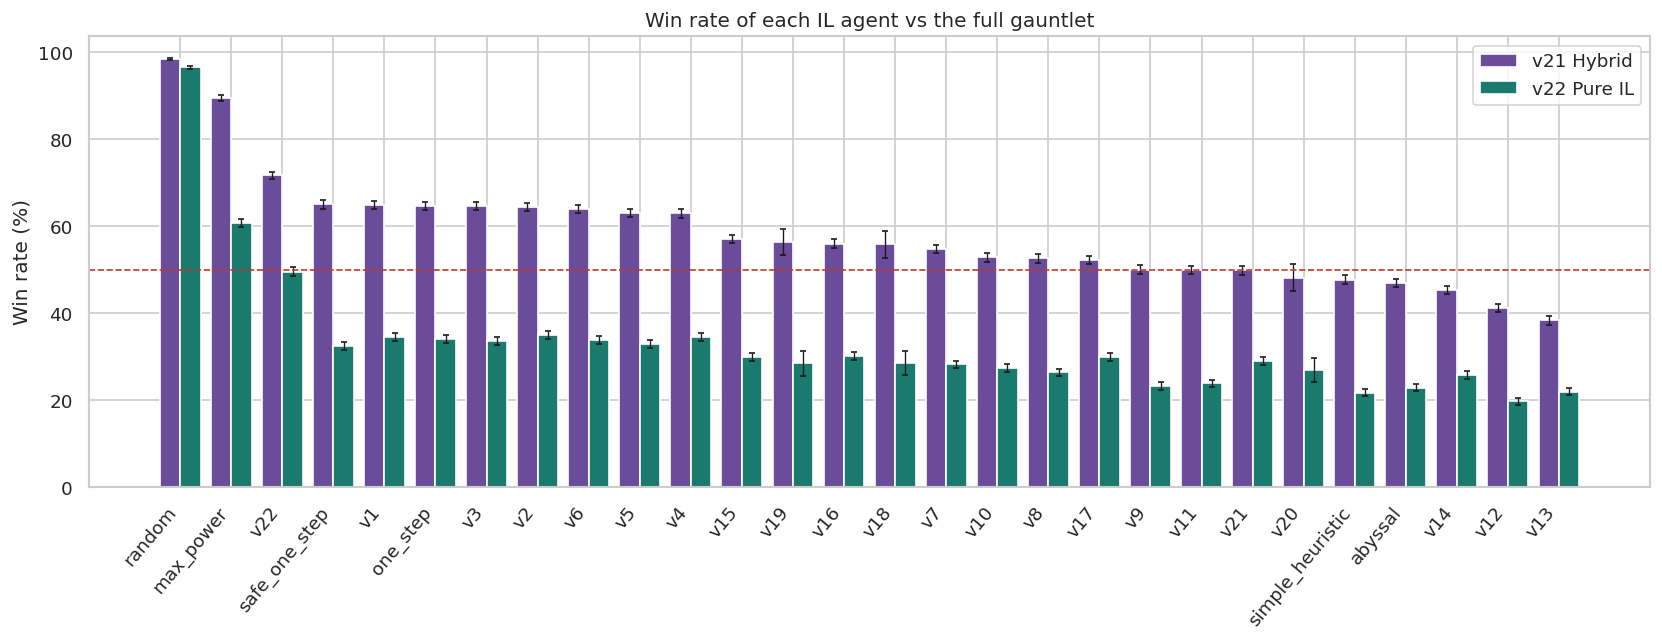

In [6]:
# Per-opponent win rates for both IL agents
def wr_table(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("matchup_opponent").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    t["paradigm"] = t.index.map(lambda x: PARADIGM_MAP.get(x, "Other"))
    return t


wr = {ag: wr_table(g) for ag, g in frames.items()}
cmp = wr["v21"].add_prefix("v21_").join(wr["v22"].add_prefix("v22_"), how="outer")
cmp["delta_pp"] = cmp["v21_win_rate"] - cmp["v22_win_rate"]
cmp = cmp.sort_values("v21_win_rate", ascending=False)
cmp.to_csv(OUTPUT_DIR / "il_winrate_by_opponent.csv")

order = list(cmp.index)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(x - 0.2, cmp.loc[order, "v21_win_rate"], 0.4, yerr=cmp.loc[order, "v21_ci95"],
       capsize=2, color=AGENT_COLOR["v21"], label="v21 Hybrid", error_kw={"elinewidth": 0.8})
ax.bar(x + 0.2, cmp.loc[order, "v22_win_rate"], 0.4, yerr=cmp.loc[order, "v22_ci95"],
       capsize=2, color=AGENT_COLOR["v22"], label="v22 Pure IL", error_kw={"elinewidth": 0.8})
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=50, ha="right")
ax.set_ylabel("Win rate (%)")
ax.set_title("Win rate of each IL agent vs the full gauntlet")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_winrate_grouped.png")
plt.show()

print(f"v21 beats v22 in {(cmp['delta_pp'] > 0).sum()} / {len(cmp)} matchups")
print(f"Mean delta (v21 − v22): {cmp['delta_pp'].mean():+.2f} pp")
print("\nLargest gaps (v21 − v22):")
print(cmp["delta_pp"].sort_values(ascending=False).head(6).to_string())
print("\nSmallest gaps (v21 − v22); v21 is ahead in every matchup if all values are positive:")
print(cmp["delta_pp"].sort_values().head(6).to_string())


## 6 · Head-to-head: v21 vs v22 sitting in opposite seats

`v21_vs_v22.csv` and `v22_vs_v21.csv` are **independent** 10k samples, not the same games
flipped. Reciprocal win rates should still sum near 1 if the matchup is well estimated.


In [7]:
# Direct v21 ↔ v22
h2h = []
for a, b in (("v21", "v22"), ("v22", "v21")):
    g = frames[a]
    sub = g[g["matchup_opponent"] == b]
    n, w = len(sub), int(sub["won_bool"].sum())
    h2h.append({
        "file": f"{a}_vs_{b}",
        "games": n,
        "win_rate_%": 100 * w / n,
        "ci95_pp": wilson_ci(w, n),
        "avg_turns": sub["turns"].mean(),
        "xgb_switch_share_%": 100 * sub["xgb_switch_share"].mean(),
        "endgame / game": sub["endgame_solves_us"].mean(),
        "ko_guards / game": sub["ko_guards_us"].mean(),
    })
h2h_df = pd.DataFrame(h2h).set_index("file")
s = h2h_df["win_rate_%"].sum() / 100
print(h2h_df.to_string())
print(f"\nWR(v21 vs v22) + WR(v22 vs v21) = {s:.4f}  (1.0 = perfectly reciprocal)")


            games  win_rate_%  ci95_pp  avg_turns  xgb_switch_share_%  endgame / game  ko_guards / game
file                                                                                                   
v21_vs_v22  10000      71.740    0.882     19.370              33.288           0.024            15.130
v22_vs_v21  10000      29.070    0.890     19.364              14.878           0.000             0.000

WR(v21 vs v22) + WR(v22 vs v21) = 1.0081  (1.0 = perfectly reciprocal)


## 7 · Switching style

v22 chooses the *incoming* Pokémon by asking the macro model “would an expert want to
switch *out* of this body?”. v21 asks v14’s matchup tables. That should change
voluntary-switch volume and how often the macro head itself votes to switch.


Means
  voluntary_switches_us       v21=1.98  v22=3.72
  forced_switches_us          v21=4.41  v22=4.79
  xgb_switches_us             v21=0.97  v22=2.88


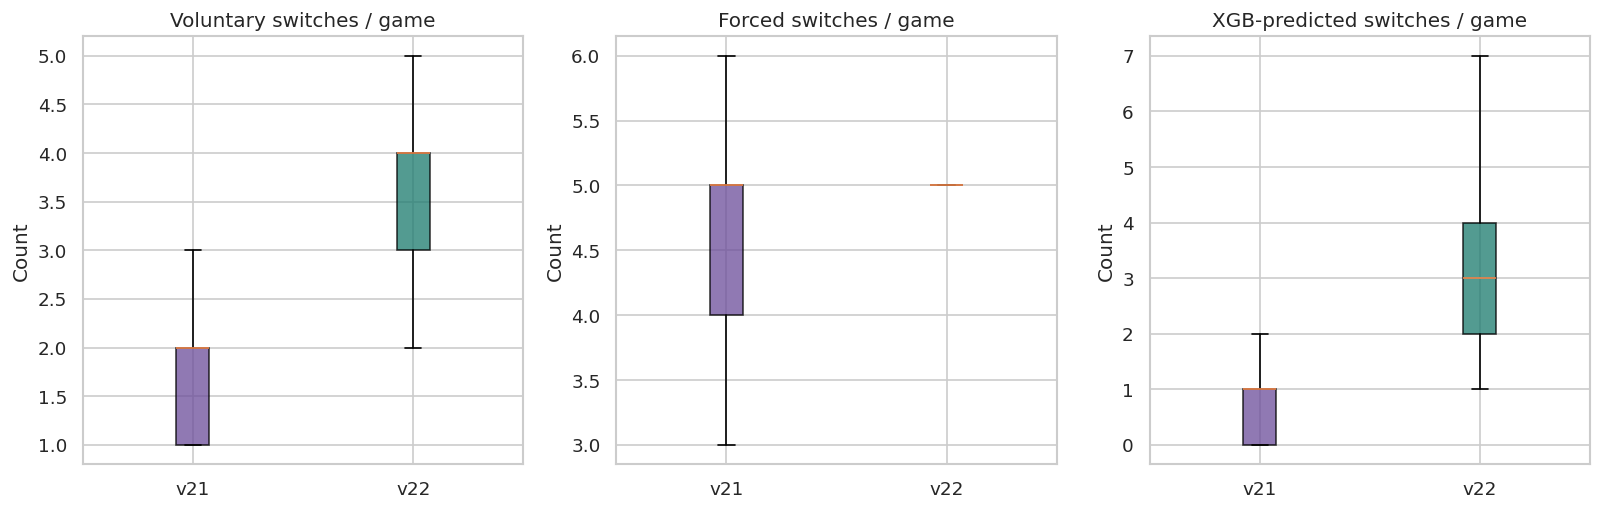

In [8]:
# Switching comparison
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

for ax, col, title in [
    (axes[0], "voluntary_switches_us", "Voluntary switches / game"),
    (axes[1], "forced_switches_us", "Forced switches / game"),
    (axes[2], "xgb_switches_us", "XGB-predicted switches / game"),
]:
    data = [frames[ag][col] for ag in AGENTS]
    bp = ax.boxplot(data, tick_labels=["v21", "v22"], patch_artist=True, showfliers=False)
    for patch, ag in zip(bp["boxes"], AGENTS):
        patch.set_facecolor(AGENT_COLOR[ag])
        patch.set_alpha(0.75)
    ax.set_title(title)
    ax.set_ylabel("Count")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_switching_box.png")
plt.show()

print("Means")
for col in ["voluntary_switches_us", "forced_switches_us", "xgb_switches_us"]:
    print(f"  {col:26s}  v21={frames['v21'][col].mean():.2f}  v22={frames['v22'][col].mean():.2f}")


## 8 · Move selection: v14 scorer vs move-evaluator XGB

v21 still uses heuristic damage math once it decides to attack. v22 scores each legal
move with a second XGBoost (base power, STAB, effectiveness, status, priority). Proxies
on the replay: super-effective hits, Terastallization, KO checks. `hazard_sets_us` and
`setup_uses_us` are unused in this benchmark schema (stay at 0 for both).


  supereffective_us       v21=4.465  v22=4.159  Δ=+0.306
  terastallized_us        v21=0.387  v22=0.990  Δ=-0.604
  hazard_sets_us          v21=0.000  v22=0.000  Δ=+0.000
  setup_uses_us           v21=0.000  v22=0.000  Δ=+0.000
  ko_checks_us            v21=0.631  v22=0.000  Δ=+0.631


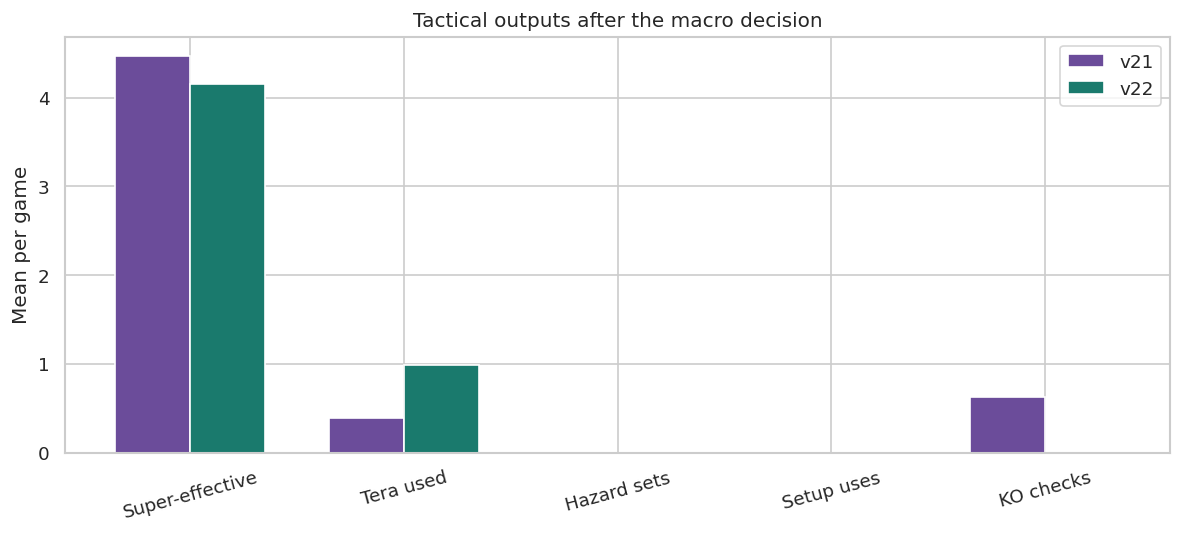

In [9]:
# Offensive / tactical proxies
proxy = ["supereffective_us", "terastallized_us", "hazard_sets_us", "setup_uses_us", "ko_checks_us"]
fig, ax = plt.subplots(figsize=(10, 4.6))
idx = np.arange(len(proxy))
w = 0.35
ax.bar(idx - w / 2, [frames["v21"][c].mean() for c in proxy], w, color=AGENT_COLOR["v21"], label="v21")
ax.bar(idx + w / 2, [frames["v22"][c].mean() for c in proxy], w, color=AGENT_COLOR["v22"], label="v22")
ax.set_xticks(idx)
ax.set_xticklabels(["Super-effective", "Tera used", "Hazard sets", "Setup uses", "KO checks"], rotation=15)
ax.set_ylabel("Mean per game")
ax.set_title("Tactical outputs after the macro decision")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_tactical_proxies.png")
plt.show()

for c in proxy:
    a, b = frames["v21"][c].mean(), frames["v22"][c].mean()
    print(f"  {c:22s}  v21={a:.3f}  v22={b:.3f}  Δ={a-b:+.3f}")


## 9 · Robustness: fallbacks, errors, loop guards

Loop guards fire when the macro model would switch two turns in a row (anti-oscillation).
A much higher rate on v22 would mean the pure policy is less stable without v14’s
tactical overrides. Fallbacks / errors should stay near zero for both.


In [10]:
# Robustness
rob = pd.DataFrame({
    ag: {
        "fallback_moves_us": g["fallback_moves_us"].mean(),
        "error_moves_us": g["error_moves_us"].mean(),
        "loop_guards_us": g["loop_guards_us"].mean(),
        "pct_games_with_loop_guard": 100 * (g["loop_guards_us"] > 0).mean(),
        "pct_games_with_fallback": 100 * (g["fallback_moves_us"] > 0).mean(),
    }
    for ag, g in frames.items()
}).T
print(rob.to_string())


     fallback_moves_us  error_moves_us  loop_guards_us  pct_games_with_loop_guard  pct_games_with_fallback
v21              0.000           0.000           0.382                     32.730                    0.000
v22              0.011           0.000           1.920                     97.247                    0.277


## 10 · Strength by opponent paradigm

Win rate against Baseline / Heuristic / Minimax / MCTS / the other IL agent. This is the
TFM question: does grafting XGB onto v14 (v21) beat a fully learned policy (v22), and
against which class of opponent?


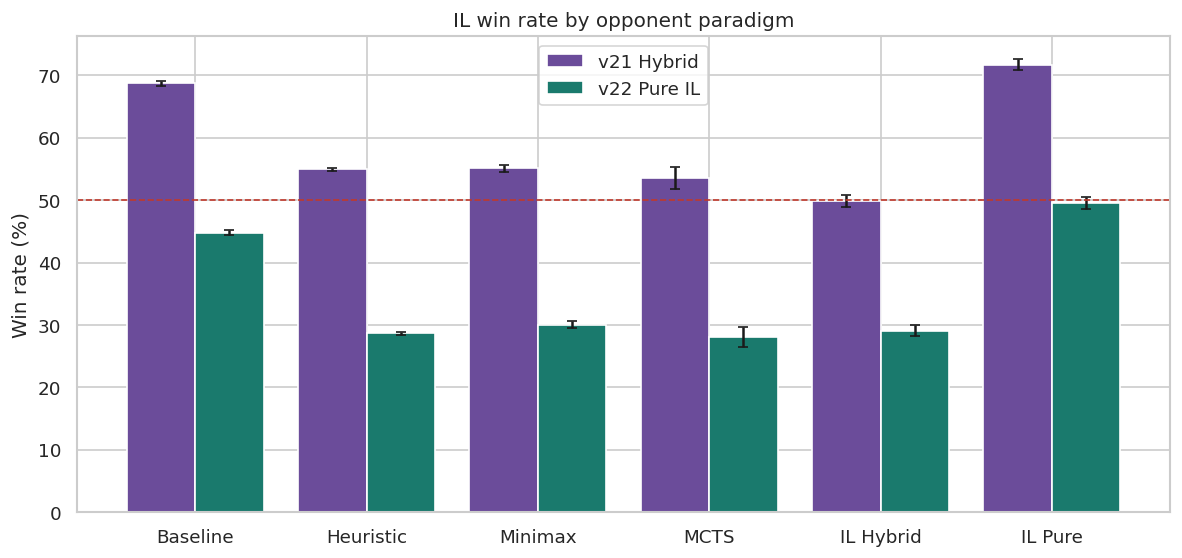

In [11]:
# Paradigm-level WR
def paradigm_wr(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("opponent_paradigm").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    return t.reindex([p for p in PARADIGM_ORDER if p in t.index])


pw = {ag: paradigm_wr(g) for ag, g in frames.items()}
labels = list(pw["v21"].index)
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - 0.2, pw["v21"]["win_rate"], 0.4, yerr=pw["v21"]["ci95"],
       capsize=3, color=AGENT_COLOR["v21"], label="v21 Hybrid")
ax.bar(x + 0.2, pw["v22"]["win_rate"], 0.4, yerr=pw["v22"]["ci95"],
       capsize=3, color=AGENT_COLOR["v22"], label="v22 Pure IL")
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Win rate (%)")
ax.set_title("IL win rate by opponent paradigm")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_wr_by_paradigm.png")
plt.show()

joined = pw["v21"].add_prefix("v21_").join(pw["v22"].add_prefix("v22_"))
joined["delta_pp"] = joined["v21_win_rate"] - joined["v22_win_rate"]
joined


## 11 · Opponent-level scatter: does v21 dominate everywhere?

Each point is one opponent. Points above the diagonal: v21 has the higher win rate.
Distance from the diagonal is the practical gap between hybrid IL and pure IL.


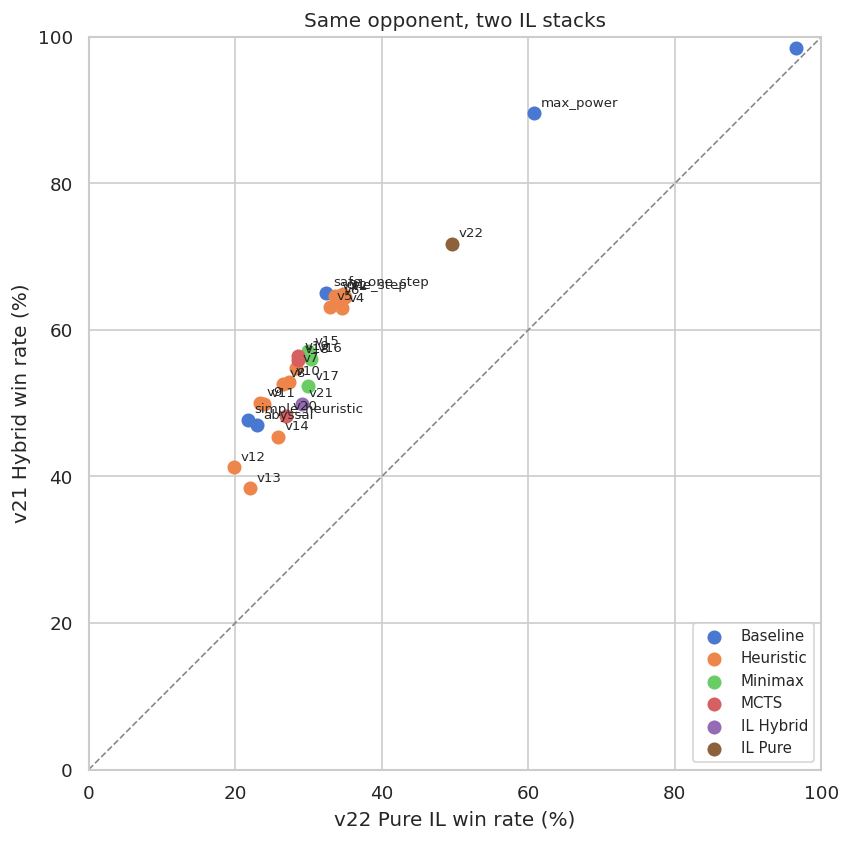

In [12]:
# Scatter WR(v21) vs WR(v22)
fig, ax = plt.subplots(figsize=(7.2, 7.2))
for paradigm in PARADIGM_ORDER:
    mask = cmp["v21_paradigm"] == paradigm
    if not mask.any():
        continue
    ax.scatter(cmp.loc[mask, "v22_win_rate"], cmp.loc[mask, "v21_win_rate"],
               s=55, label=paradigm, zorder=3)
for opp, r in cmp.iterrows():
    if abs(r["delta_pp"]) >= 8:
        ax.annotate(opp, (r["v22_win_rate"], r["v21_win_rate"]), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
lo, hi = 0, 100
ax.plot([lo, hi], [lo, hi], color="#888", ls="--", lw=1)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("v22 Pure IL win rate (%)")
ax.set_ylabel("v21 Hybrid win rate (%)")
ax.set_title("Same opponent, two IL stacks")
ax.legend(loc="lower right", fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_wr_scatter.png")
plt.show()


## 12 · Game length and remaining HP

Pure IL without v14’s KO sniping / endgame solver may play longer or leave more HP on
the board. Compare turn counts and remaining Pokémon after the battle.


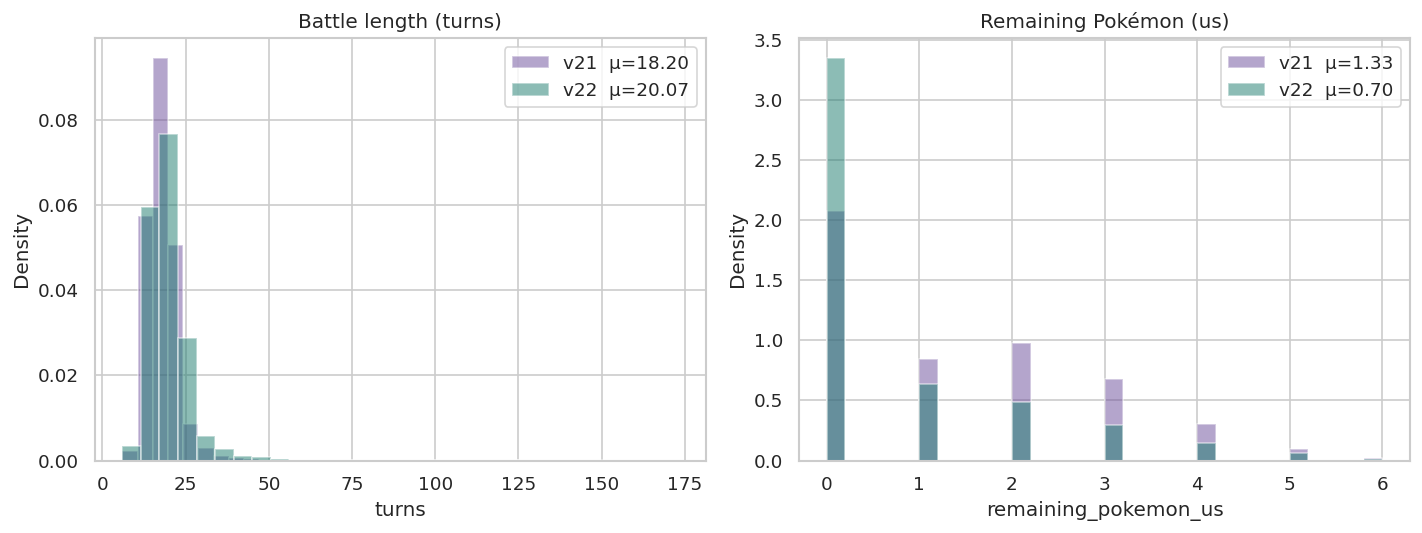

In [13]:
# Duration and leftover HP
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, col, title in [
    (axes[0], "turns", "Battle length (turns)"),
    (axes[1], "remaining_pokemon_us", "Remaining Pokémon (us)"),
]:
    for ag, g in frames.items():
        ax.hist(g[col], bins=30, density=True, alpha=0.5, color=AGENT_COLOR[ag],
                label=f"{ag}  μ={g[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "il_length_hp.png")
plt.show()


## 13 · Self-play sanity

Each agent vs itself should sit near 50%. A large deviation would mean a recording-seat
bias, not a policy difference.


In [14]:
# Self-play
for ag, g in frames.items():
    sub = g[g["matchup_opponent"] == ag]
    n, w = len(sub), int(sub["won_bool"].sum())
    wr = 100 * w / n
    print(f"  {ag} vs {ag}:  {wr:.2f}%  ±{wilson_ci(w, n):.2f}  (n={n:,})")


  v21 vs v21:  49.92%  ±0.98  (n=10,000)
  v22 vs v22:  49.58%  ±0.98  (n=10,000)


## 14 · Export comparison report


In [15]:
# Markdown report
best_v21 = cmp["v21_win_rate"].idxmax()
worst_v21 = cmp["v21_win_rate"].idxmin()
best_v22 = cmp["v22_win_rate"].idxmax()
worst_v22 = cmp["v22_win_rate"].idxmin()
biggest = cmp["delta_pp"].abs().idxmax()

lines = [
    "# Imitation Learning EDA — v21 Hybrid vs v22 Pure",
    "",
    "Source: `data/benchmarks/all_10k/gen9randombattle` (each agent as us vs 28 opponents).",
    "",
    "## Architecture in one paragraph",
    "",
    "Both agents share the 1,150-feature XGBoost **macro** model (move vs switch, τ = 0.5525).",
    "**v21** is a hybrid: v14 guaranteed-KO, endgame minimax, setup/status logic run *before*",
    "XGBoost; remaining move/switch execution is still v14. **v22** is synthetic move head: the same",
    "macro head, then a second XGBoost for move choice and counterfactual bench scoring for",
    "switches — zero HeuristicV14.",
    "",
    "## Headline",
    "",
    headline.to_markdown(),
    "",
    "## Fingerprint (mean per game)",
    "",
    fp_df[display_cols].T.to_markdown(),
    "",
    "## Head-to-head",
    "",
    h2h_df.to_markdown(),
    "",
    f"Reciprocal sum = {s:.4f}",
    "",
    "## Matchup notes",
    "",
    f"- v21 best: `{best_v21}` ({cmp.loc[best_v21, 'v21_win_rate']:.1f}%)",
    f"- v21 worst: `{worst_v21}` ({cmp.loc[worst_v21, 'v21_win_rate']:.1f}%)",
    f"- v22 best: `{best_v22}` ({cmp.loc[best_v22, 'v22_win_rate']:.1f}%)",
    f"- v22 worst: `{worst_v22}` ({cmp.loc[worst_v22, 'v22_win_rate']:.1f}%)",
    f"- Largest |WR gap|: `{biggest}` (v21 − v22 = {cmp.loc[biggest, 'delta_pp']:+.1f} pp)",
    f"- v21 ahead in {(cmp['delta_pp'] > 0).sum()} / {len(cmp)} opponents (mean Δ {cmp['delta_pp'].mean():+.2f} pp)",
    "",
    "## Paradigm win rates",
    "",
    joined.to_markdown(),
    "",
    "## Figures",
    "",
    "- `il_fingerprint_bars.png`",
    "- `il_policy_firing.png`",
    "- `il_winrate_grouped.png`",
    "- `il_switching_box.png`",
    "- `il_tactical_proxies.png`",
    "- `il_wr_by_paradigm.png`",
    "- `il_wr_scatter.png`",
    "- `il_length_hp.png`",
]

report_path = OUTPUT_DIR / "il_v21_v22_comparison.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")
print(f"Plots in {OUTPUT_DIR}")


Wrote /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/il_v21_v22/il_v21_v22_comparison.md
Plots in /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/il_v21_v22
